In [16]:
"""
Attempt to make better plots than in 'plotting_gain_...' using the peak finding function or metrics
from the micro-circuit/ folder.

Namely:
    - plot as a function of number of spikes
    - plot of spike train entropy?
    - plot as fourier transform distribution?

(instantaneous frequency can stay the same)
"""

"\nAttempt to make better plots than in 'plotting_gain_...' using the peak finding function or metrics\nfrom the micro-circuit/ folder.\n\nNamely:\n    - plot as a function of number of spikes\n    - plot of spike train entropy?\n    - plot as fourier transform distribution?\n\n(instantaneous frequency can stay the same)\n"

In [17]:
import sys
sys.path.append("..//")

import aqua
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.stimulus import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_theme()
import pickle
import random


from simulation import get_F

In [18]:
# import data
SAVE = False
neuron = "RS_intHD_uniform_biexp"
out_dir = f".//{neuron}//"

filename = f"{neuron}_GAIN.pickle"
with open(out_dir + filename, 'rb') as file:
    df = pickle.load(file)

print(df.keys())
print(df.head())
print(np.sort(df['f'].unique()))
print('--------')
print(np.sort(df['I_h'].unique()))

print(df['e'].unique())
e = df['e'].unique()[3]
print(e)

Index(['e', 'f', 'tau', 'autapse current', 'autapse delay', 'I_h', 'F_instant',
       'F_steady', 'num_frequencies', 'entropy'],
      dtype='object')
     e     f  tau  autapse current  autapse delay  I_h  F_instant  F_steady  \
0  0.0   0.0  0.0         0.000000            NaN  0.0        NaN       NaN   
1  0.1  60.0  0.0       774.929799       6.931472  0.0        NaN       NaN   
2  0.1  60.0  2.0       774.929799       8.931472  0.0        NaN       NaN   
3  0.1  60.0  4.0       774.929799      10.931472  0.0        NaN       NaN   
4  0.2  60.0  0.0       448.604634       3.465736  0.0        NaN       NaN   

   num_frequencies  entropy  
0                0      NaN  
1                0      NaN  
2                0      NaN  
3                0      NaN  
4                0      NaN  
[  0.  60.  80. 100. 120. 140. 160. 180. 200. 220. 240. 260. 280. 300.
 320. 340. 360. 380. 400. 420. 440. 460.]
--------
[  0.           1.25628141   2.51256281   3.76884422   5.02512563
   6.

     e     f  tau  autapse current  autapse delay  I_h  F_instant  F_steady  \
0  0.0   0.0  0.0         0.000000            NaN  0.0        NaN       NaN   
1  0.1  60.0  0.0       774.929799       6.931472  0.0        NaN       NaN   
2  0.1  60.0  2.0       774.929799       8.931472  0.0        NaN       NaN   
3  0.1  60.0  4.0       774.929799      10.931472  0.0        NaN       NaN   
4  0.2  60.0  0.0       448.604634       3.465736  0.0        NaN       NaN   

   num_frequencies  entropy  
0                0      NaN  
1                0      NaN  
2                0      NaN  
3                0      NaN  
4                0      NaN  


Text(0.5, 0.98, 'Firing Frequencies versus net current and mean delay of the autapse ')

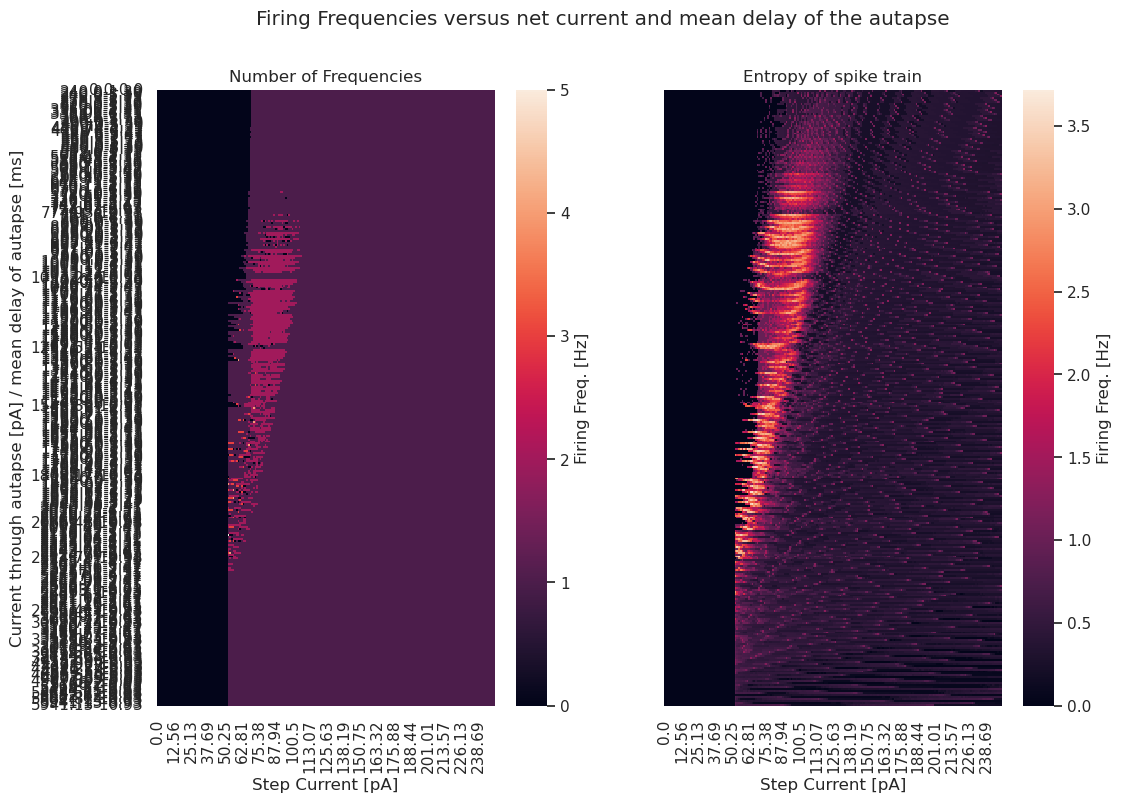

In [19]:
fig, ax = plt.subplots(1, 2, figsize = (12, 8), sharey = True)

#temp_df = df[(df['tau'] == 2.0) & (df['e'] == e)] # & (df['f'] == 250.0)]
#temp_df = df[(df['f'] > 399.0) & (df['f'] < 401)] 
#current = np.array(df['autapse current'].unique())
#target = current[np.argmin(np.abs(current[~np.isnan(current)] - 1250))]
#temp_df = df[df['autapse current'] == target]
temp_df = df.copy()
print(temp_df.head())

#temp_df['temp_id'] = temp_df.groupby(['autapse delay', 'I_h']).cumcount()
temp_df = temp_df.round(decimals = 2)
temp_df= temp_df.fillna(0.)

num_peaks_df = (temp_df.pivot(index = ['autapse current', 'autapse delay'], columns = 'I_h', values = 'num_frequencies'))
entropy_df = (temp_df.pivot(index = ['autapse current', 'autapse delay'], columns = 'I_h', values = 'entropy'))

sns.heatmap(num_peaks_df, annot = False, linewidth = 0., ax = ax[0], xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'})
sns.heatmap(entropy_df, annot = False, linewidth = 0., ax = ax[1], xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'})

ax[0].set_xlabel('Step Current [pA]')
ax[1].set_xlabel('Step Current [pA]')

ax[0].set_ylabel('Current through autapse [pA] / mean delay of autapse [ms]')
ax[1].set_ylabel('')

ax[0].set_title('Number of Frequencies')
ax[1].set_title('Entropy of spike train')

fig.suptitle('Firing Frequencies versus net current and mean delay of the autapse ')


In [20]:
print(np.linspace(60, 460, 21))

[ 60.  80. 100. 120. 140. 160. 180. 200. 220. 240. 260. 280. 300. 320.
 340. 360. 380. 400. 420. 440. 460.]


Text(0.5, 0.98, 'Firing Frequencies versus net current and mean delay of the autapse ')

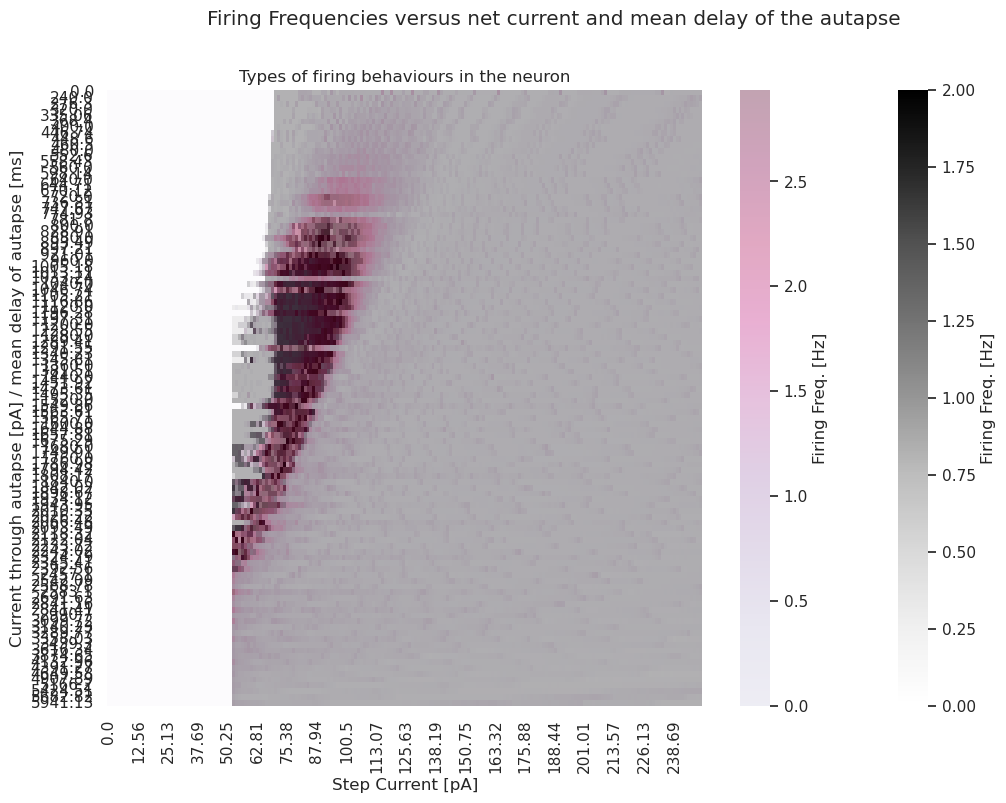

In [21]:
fig, ax = plt.subplots(1, 1, figsize = (12, 8))

temp_df = df.copy()

#temp_df['temp_id'] = temp_df.groupby(['autapse delay', 'I_h']).cumcount()
temp_df = temp_df.round(decimals = 2)
temp_df= temp_df.fillna(0.)


current_df = temp_df.pivot_table(
    index='autapse current', 
    columns='I_h', 
    values='num_frequencies', 
    aggfunc='mean'
)

entropy_df = temp_df.pivot_table(
    index='autapse current', 
    columns='I_h', 
    values='entropy', 
    aggfunc='mean'
)


sns.heatmap(current_df, annot = False, linewidth = 0., ax = ax, xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'}, 
            cmap = 'Greys', alpha = 1.0, vmin = 0., vmax = 2.0)
sns.heatmap(entropy_df, annot = False, linewidth = 0., ax = ax, xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'}, 
            cmap = 'PuRd', alpha = 0.3)



ax.set_xlabel('Step Current [pA]')

ax.set_ylabel('Current through autapse [pA] / mean delay of autapse [ms]')

ax.set_title('Types of firing behaviours in the neuron')

fig.suptitle('Firing Frequencies versus net current and mean delay of the autapse ')

Text(0.5, 0.98, 'Firing Frequencies versus net current and mean delay of the autapse ')

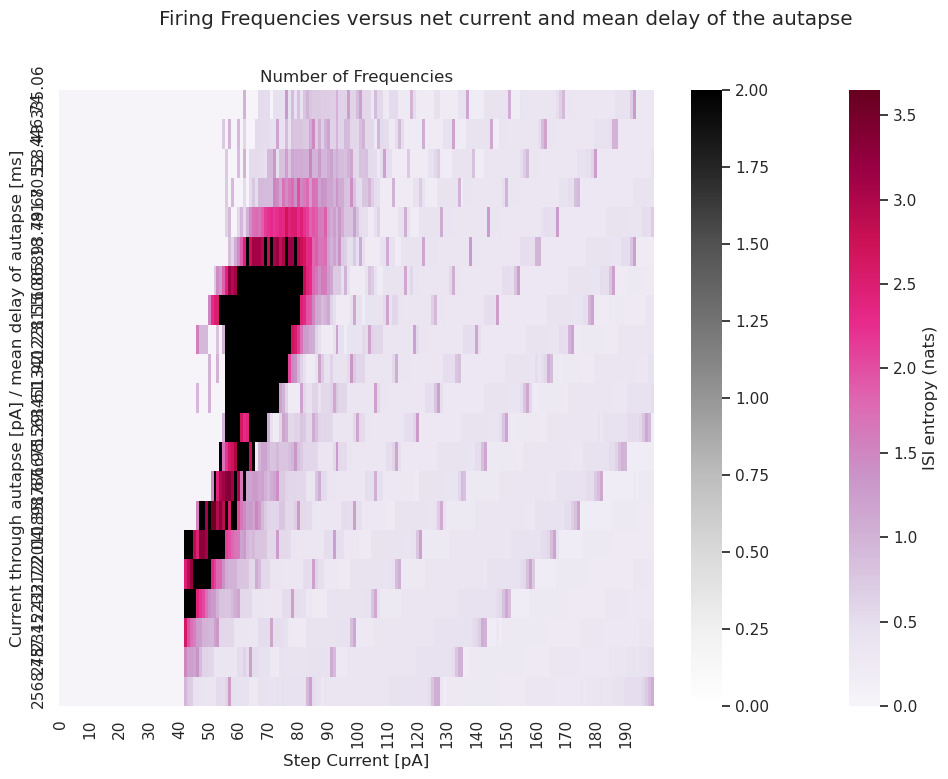

In [22]:
fig, ax = plt.subplots(1, 1, figsize = (12, 8))

#temp_df = df.copy()
temp_df = df[(df['tau'] == 2.0) & (df['e'] == e)]

#temp_df['temp_id'] = temp_df.groupby(['autapse delay', 'I_h']).cumcount()
temp_df = temp_df.round(decimals = 2)
temp_df= temp_df.fillna(0.)


current_df = temp_df.pivot_table(
    index='autapse current', 
    columns='I_h', 
    values='num_frequencies', 
    aggfunc='mean'
)

entropy_df = temp_df.pivot_table(
    index='autapse current', 
    columns='I_h', 
    values='entropy', 
    aggfunc='mean'
)

current_vals = current_df.index
current_arr = np.array(current_df)
current_arr[np.where(current_arr <= 1.0)] = np.nan

sns.heatmap(entropy_df, annot = False, linewidth = 0., ax = ax, xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'ISI entropy (nats)'}, 
            cmap = 'PuRd', alpha = 1.0)

sns.heatmap(current_arr, annot = False, linewidth = 0., ax = ax, xticklabels = 10, yticklabels = True,
            cmap = 'Greys', alpha = 1.0, vmin = 0., vmax = 2.0)

ax.set_yticks(np.arange(len(current_vals)), labels = current_vals)
ax.set_xlabel('Step Current [pA]')

ax.set_ylabel('Current through autapse [pA] / mean delay of autapse [ms]')

ax.set_title('Number of Frequencies')

fig.suptitle('Firing Frequencies versus net current and mean delay of the autapse ')

WARNING    /tmp/ipykernel_37460/3919099176.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('viridis')
 [py.warnings]


Text(0.5, 0.98, 'Firing Frequencies versus net current and mean delay of the autapse ')

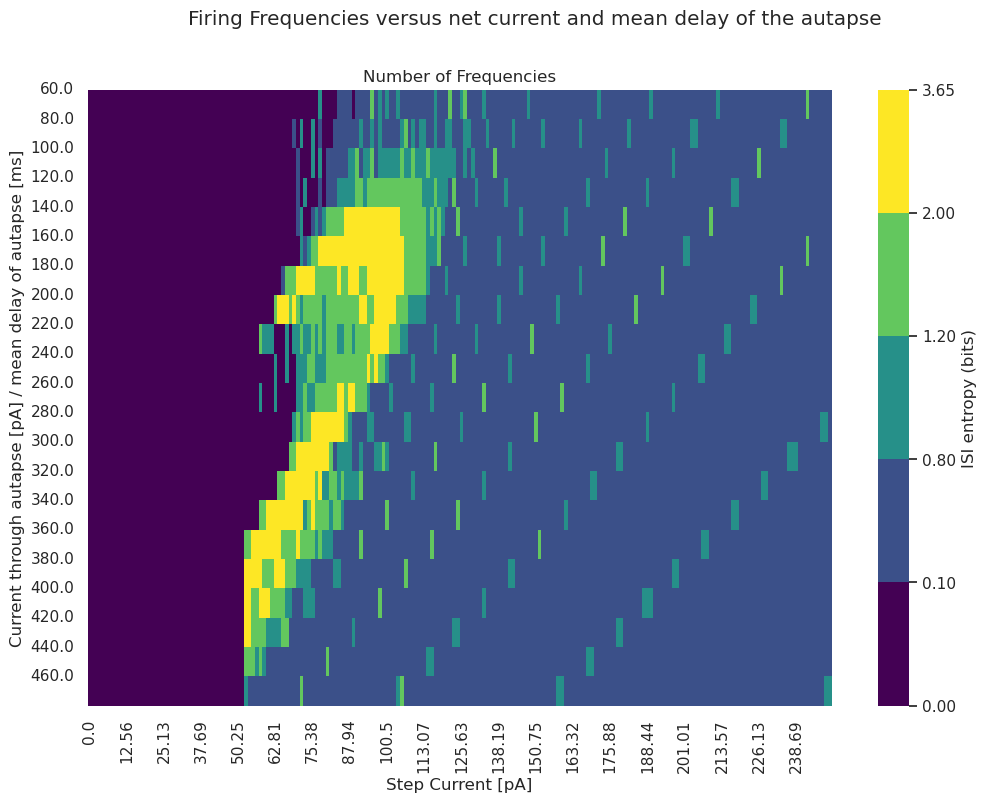

In [23]:
fig, ax = plt.subplots(1, 1, figsize = (12, 8))

#temp_df = df.copy()
temp_df = df[(df['tau'] == 2.0) & (df['e'] == e)]

#temp_df['temp_id'] = temp_df.groupby(['autapse delay', 'I_h']).cumcount()
temp_df = temp_df.round(decimals = 2)
temp_df= temp_df.fillna(0.)


current_df = temp_df.pivot_table(
    index='f', 
    columns='I_h', 
    values='num_frequencies', 
    aggfunc='mean'
)

entropy_df = temp_df.pivot_table(
    index='f', 
    columns='I_h', 
    values='entropy', 
    aggfunc='mean'
)

current_vals = current_df.index
current_arr = np.array(current_df)
current_arr[np.where(current_arr <= 1.0)] = np.nan

# define a categorical colour map
bounds = [0.0, 0.1, 0.8, 1.2, 2.0, np.max(entropy_df.values)]

base_cmap = plt.cm.get_cmap('viridis')
sample_pts = np.linspace(0.0, 1.0, len(bounds))
colors = base_cmap(sample_pts)
cmap = mcolors.LinearSegmentedColormap.from_list('viridis_cropped', colors)

#colors = ["#440154", "#31688e", "#35b779", "#fde725"]
#cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

sns.heatmap(entropy_df, annot = False, linewidth = 0., ax = ax, xticklabels = 10, yticklabels = True, 
            cmap = cmap, norm = norm, cbar_kws = {'label': 'ISI entropy (bits)', 'ticks': bounds})


ax.set_yticks(np.arange(len(current_vals)), labels = current_vals)
ax.set_xlabel('Step Current [pA]')

ax.set_ylabel('Current through autapse [pA] / mean delay of autapse [ms]')

ax.set_title('Number of Frequencies')

fig.suptitle('Firing Frequencies versus net current and mean delay of the autapse ')

WARNING    /tmp/ipykernel_37460/3309175782.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('viridis')
 [py.warnings]


F VALUES: 8         60.0
23        80.0
38       100.0
53       120.0
68       140.0
         ...  
63132    380.0
63147    400.0
63162    420.0
63177    440.0
63192    460.0
Name: f, Length: 4200, dtype: float64


Text(0.5, 0.98, 'Firing Frequencies versus net current and mean delay of the autapse ')

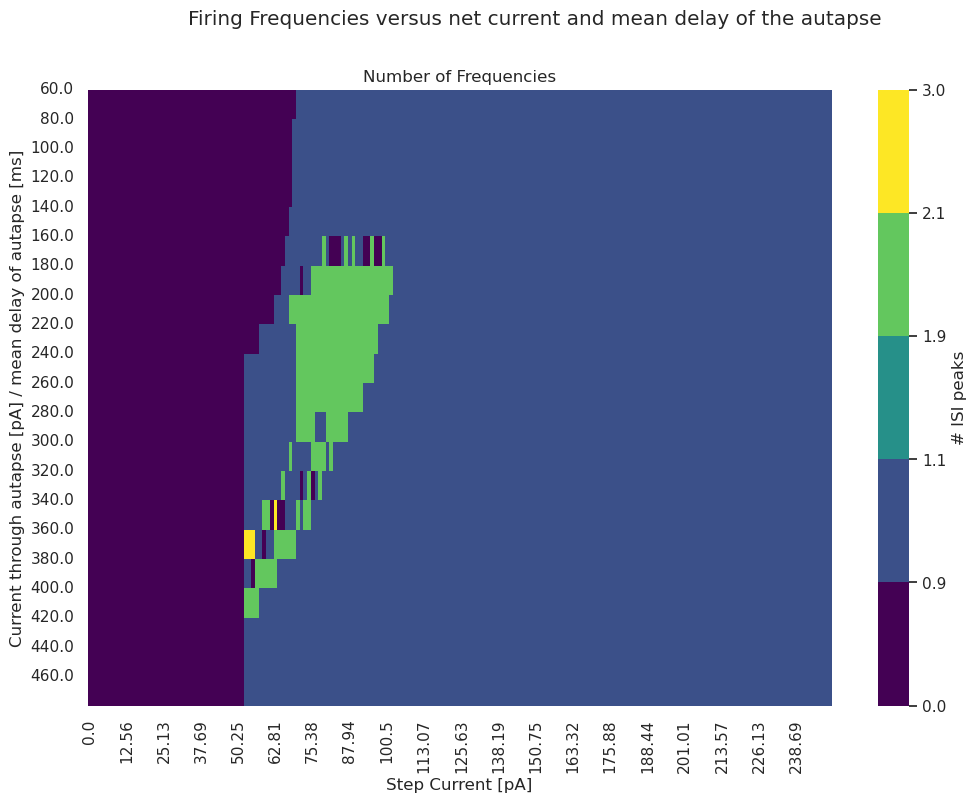

In [26]:
fig, ax = plt.subplots(1, 1, figsize = (12, 8))

#temp_df = df.copy()
temp_df = df[(df['tau'] == 2.0) & (df['e'] == e)]

#temp_df['temp_id'] = temp_df.groupby(['autapse delay', 'I_h']).cumcount()
temp_df = temp_df.round(decimals = 2)
temp_df= temp_df.fillna(0.)

print(f'F VALUES: {temp_df['f']}')

current_df = temp_df.pivot_table(
    index='f', 
    columns='I_h', 
    values='num_frequencies', 
    aggfunc='mean'
)

entropy_df = temp_df.pivot_table(
    index='autapse current', 
    columns='I_h', 
    values='entropy', 
    aggfunc='mean'
)

current_vals = current_df.index
current_arr = np.array(current_df)
current_arr[np.where(current_arr <= 1.0)] = np.nan

# define a categorical colour map
bounds = [0.0, 0.9, 1.1, 1.9, 2.1, np.max(current_df.values)]

base_cmap = plt.cm.get_cmap('viridis')
sample_pts = np.linspace(0.0, 1.0, len(bounds))
colors = base_cmap(sample_pts)
cmap = mcolors.LinearSegmentedColormap.from_list('viridis_cropped', colors)

#colors = ["#440154", "#31688e", "#35b779", "#fde725"]
#cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

sns.heatmap(current_df, annot = False, linewidth = 0., ax = ax, xticklabels = 10, yticklabels = True, 
            cmap = cmap, norm = norm, cbar_kws = {'label': '# ISI peaks', 'ticks': bounds})


ax.set_yticks(np.arange(len(current_vals)), labels = current_vals)
ax.set_xlabel('Step Current [pA]')

ax.set_ylabel('Current through autapse [pA] / mean delay of autapse [ms]')

ax.set_title('Number of Frequencies')

fig.suptitle('Firing Frequencies versus net current and mean delay of the autapse ')

<Axes: ylabel='Count'>

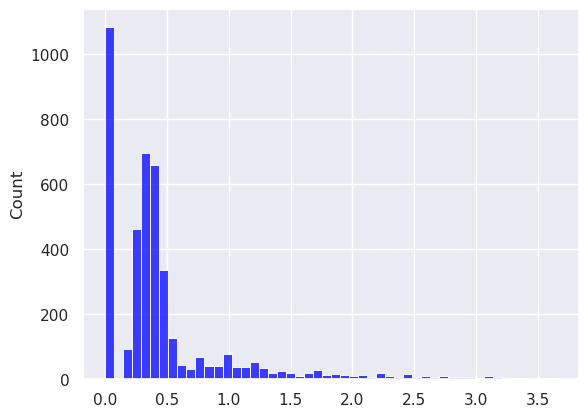

In [25]:
sns.histplot(entropy_df.values.flatten(), bins = 50, color = 'blue')